In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import warnings
import subprocess
import json
import joblib
from datetime import datetime
from PIL import Image
import requests
from io import BytesIO

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Skimage for feature extraction
from skimage.feature import local_binary_pattern, hog
from skimage import exposure

# Ignore warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
!pip install kagglehub

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -----------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aniruddhsharma/structural-defects-network-concrete-crack-images")

print("Path to dataset files:", path)

100%|██████████| 506M/506M [00:56<00:00, 9.38MB/s] 

Extracting files...


Path to dataset files: C:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1


In [9]:
path = r"c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1"

📂 Loading SDNET dataset...
   Path: c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1

📁 Processing Decks:
   ✓ Found 100 cracked images

📁 Processing Pavements:
   ✓ Found 100 cracked images

📁 Processing Walls:
   ✓ Found 100 cracked images

✅ Total loaded: 300 images
   Cracks: 300
   No Cracks: 0


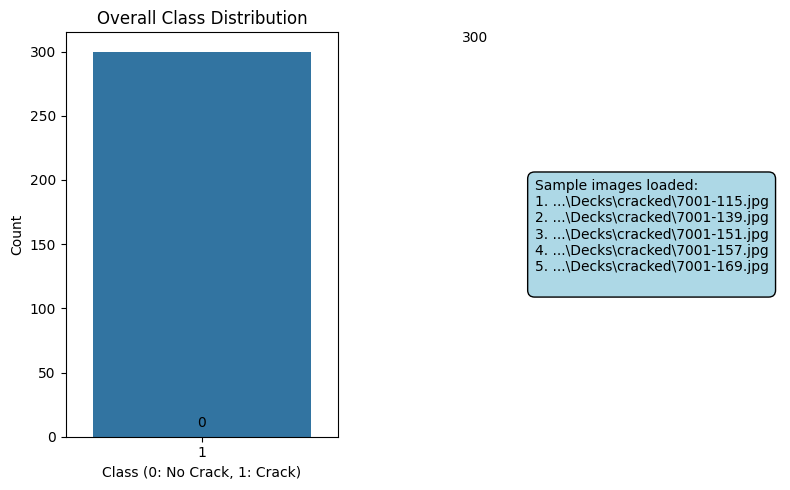


📸 First 5 image paths:
   1. c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1\Decks\cracked\7001-115.jpg
   2. c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1\Decks\cracked\7001-139.jpg
   3. c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1\Decks\cracked\7001-151.jpg
   4. c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1\Decks\cracked\7001-157.jpg
   5. c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1\Decks\cracked\7001-169.jpg


In [12]:
def load_dataset(data_path, sample_size=500):
    """
    Load SDNET dataset from the correct folder structure
    Path: .../versions/1/
    Contains folders: Decks/, Pavements/, Walls/
    Each has: cracked/, uncracked/
    """
    
    image_paths = []
    labels = []
    
    print("📂 Loading SDNET dataset...")
    print(f"   Path: {data_path}")
    
    # Check if path exists
    if not os.path.exists(data_path):
        print(f"❌ Path {data_path} does not exist!")
        return np.array(image_paths), np.array(labels)
    
    # The three main categories in SDNET
    categories = ['Decks', 'Pavements', 'Walls']
    
    for category in categories:
        category_path = os.path.join(data_path, category)
        if not os.path.exists(category_path):
            print(f"   ⚠️ {category} folder not found, skipping...")
            continue
            
        print(f"\n📁 Processing {category}:")
        
        # Process cracked images
        crack_path = os.path.join(category_path, 'cracked')
        if os.path.exists(crack_path):
            crack_images = [f for f in os.listdir(crack_path) 
                          if f.endswith(('.jpg', '.jpeg', '.png'))][:sample_size//3]
            for img_name in crack_images:
                img_path = os.path.join(crack_path, img_name)
                image_paths.append(img_path)
                labels.append(1)  # 1 for crack
            print(f"   ✓ Found {len(crack_images)} cracked images")
        
        # Process uncracked images
        uncracked_path = os.path.join(category_path, 'uncracked')
        if os.path.exists(uncracked_path):
            uncracked_images = [f for f in os.listdir(uncracked_path) 
                              if f.endswith(('.jpg', '.jpeg', '.png'))][:sample_size//3]
            for img_name in uncracked_images:
                img_path = os.path.join(uncracked_path, img_name)
                image_paths.append(img_path)
                labels.append(0)  # 0 for no crack
            print(f"   ✓ Found {len(uncracked_images)} uncracked images")
    
    print(f"\n✅ Total loaded: {len(image_paths)} images")
    print(f"   Cracks: {labels.count(1)}")
    print(f"   No Cracks: {labels.count(0)}")
    
    return np.array(image_paths), np.array(labels)

# Your specific path
path = r"c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1"

# Load the data
image_paths, labels = load_dataset(path, sample_size=300)  # 100 from each category

# Display class distribution
if len(labels) > 0:
    plt.figure(figsize=(8, 5))
    
    # Plot overall distribution
    plt.subplot(1, 2, 1)
    sns.countplot(x=labels)
    plt.title('Overall Class Distribution')
    plt.xlabel('Class (0: No Crack, 1: Crack)')
    plt.ylabel('Count')
    
    # Add value labels on bars
    for i, v in enumerate([labels.tolist().count(0), labels.tolist().count(1)]):
        plt.text(i, v + 5, str(v), ha='center', va='bottom')
    
    # Show first few image paths as sample
    plt.subplot(1, 2, 2)
    sample_text = "Sample images loaded:\n"
    for i in range(min(5, len(image_paths))):
        path_parts = image_paths[i].split('\\')
        sample_text += f"{i+1}. ...\\{path_parts[-3]}\\{path_parts[-2]}\\{path_parts[-1]}\n"
    
    plt.text(0.1, 0.5, sample_text, fontsize=10, va='center', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue"))
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📸 First 5 image paths:")
    for i in range(min(5, len(image_paths))):
        print(f"   {i+1}. {image_paths[i]}")

In [13]:
# Quick verification of your dataset structure
print("🔍 Verifying dataset structure...")
print(f"Root path: {path}")

# List all folders in the root
if os.path.exists(path):
    folders = os.listdir(path)
    print(f"\nFolders found: {folders}")
    
    # Check each category
    for folder in folders:
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            subfolders = os.listdir(folder_path)
            print(f"\n📁 {folder}/ contains: {subfolders}")
            
            # Check cracked and uncracked counts
            cracked_path = os.path.join(folder_path, 'cracked')
            uncracked_path = os.path.join(folder_path, 'uncracked')
            
            if os.path.exists(cracked_path):
                crack_count = len([f for f in os.listdir(cracked_path) 
                                 if f.endswith(('.jpg', '.png', '.jpeg'))])
                print(f"   - cracked/ : {crack_count} images")
            
            if os.path.exists(uncracked_path):
                uncracked_count = len([f for f in os.listdir(uncracked_path) 
                                     if f.endswith(('.jpg', '.png', '.jpeg'))])
                print(f"   - uncracked/ : {uncracked_count} images")
else:
    print(f"❌ Path does not exist: {path}")

🔍 Verifying dataset structure...
Root path: c:\Users\pragy\.cache\kagglehub\datasets\aniruddhsharma\structural-defects-network-concrete-crack-images\versions\1

Folders found: ['Decks', 'Pavements', 'Walls']

📁 Decks/ contains: ['Cracked', 'Non-cracked']
   - cracked/ : 2025 images

📁 Pavements/ contains: ['Cracked', 'Non-cracked']
   - cracked/ : 2608 images

📁 Walls/ contains: ['Cracked', 'Non-cracked']
   - cracked/ : 3851 images


In [14]:
def extract_features(image_path):
    """
    Extract features from image for crack detection
    """
    try:
        # Read image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"❌ Could not read image: {image_path}")
            return None
        
        # Resize for consistency
        img = cv2.resize(img, (128, 128))
        
        features = []
        
        # 1. Basic statistical features
        features.append(np.mean(img))           # Mean intensity
        features.append(np.std(img))            # Standard deviation
        features.append(np.percentile(img, 75) - np.percentile(img, 25))  # IQR
        features.append(np.median(img))         # Median
        features.append(np.sum(img > 200) / (128*128))  # Bright pixel ratio
        features.append(np.sum(img < 50) / (128*128))   # Dark pixel ratio
        
        # 2. Edge features (important for crack detection)
        edges = cv2.Canny(img, 50, 150)
        edge_density = np.sum(edges > 0) / (img.shape[0] * img.shape[1])
        features.append(edge_density)
        
        # Edge statistics
        features.append(np.mean(edges))
        features.append(np.std(edges))
        
        # 3. Texture features using Local Binary Pattern
        lbp = local_binary_pattern(img, 8, 1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
        lbp_hist = lbp_hist / (np.sum(lbp_hist) + 1e-6)  # Normalize
        features.extend(lbp_hist)
        
        # 4. HOG features
        hog_features = hog(img, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), feature_vector=True)
        # Take statistics of HOG features
        features.append(np.mean(hog_features))
        features.append(np.std(hog_features))
        features.append(np.max(hog_features))
        features.append(np.min(hog_features))
        
        # 5. Fourier transform features (frequency domain)
        f_transform = np.fft.fft2(img)
        f_shift = np.fft.fftshift(f_transform)
        magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)
        features.append(np.mean(magnitude_spectrum))
        features.append(np.std(magnitude_spectrum))
        
        return np.array(features)
    
    except Exception as e:
        print(f"❌ Error extracting features from {image_path}: {e}")
        return None

# Test feature extraction
if len(image_paths) > 0:
    test_features = extract_features(image_paths[0])
    if test_features is not None:
        print(f"✅ Feature extraction working!")
        print(f"   Feature vector shape: {test_features.shape}")
        print(f"   Number of features: {len(test_features)}")
        print(f"   Sample features: {test_features[:5]}")

✅ Feature extraction working!
   Feature vector shape: (25,)
   Number of features: 25
   Sample features: [1.79083130e+02 8.87609608e+00 9.00000000e+00 1.80000000e+02
 8.42285156e-03]


In [15]:
# Extract features from all images
print("🔄 Extracting features from all images...")

X = []
y = []
valid_paths = []

for i, (img_path, label) in enumerate(zip(image_paths, labels)):
    features = extract_features(img_path)
    if features is not None:
        X.append(features)
        y.append(label)
        valid_paths.append(img_path)
    
    # Print progress
    if (i + 1) % 50 == 0:
        print(f"  Processed {i + 1}/{len(image_paths)} images")

X = np.array(X)
y = np.array(y)

print(f"\n✅ Feature extraction complete!")
print(f"   Final dataset shape: {X.shape}")
print(f"   Samples: {len(X)}, Features: {X.shape[1] if len(X) > 0 else 0}")

🔄 Extracting features from all images...
  Processed 50/300 images
  Processed 100/300 images
  Processed 150/300 images
  Processed 200/300 images
  Processed 250/300 images
  Processed 300/300 images

✅ Feature extraction complete!
   Final dataset shape: (300, 25)
   Samples: 300, Features: 25


📊 Data Split Complete:
   Training set: 240 images
   Testing set: 60 images
   Training class distribution:
     No Crack: 0
     Crack: 240
   Testing class distribution:
     No Crack: 0
     Crack: 60


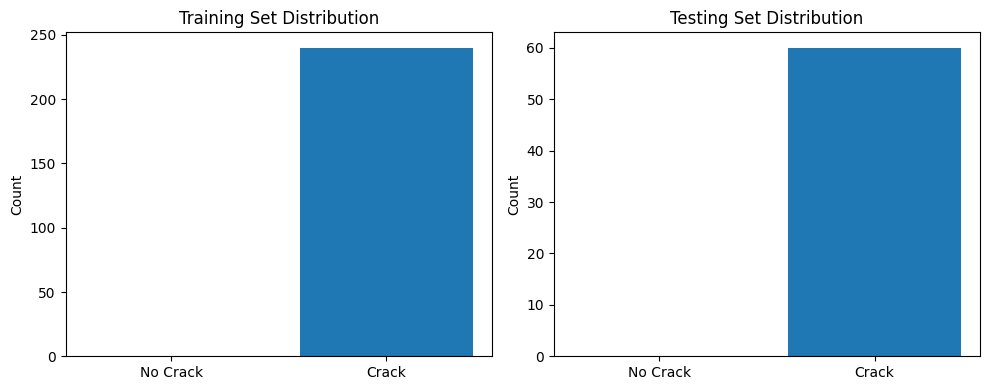

In [16]:
# Split the data
if len(X) > 0:
    X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
        X, y, valid_paths, test_size=0.2, random_state=42, stratify=y
    )
    
    print("📊 Data Split Complete:")
    print(f"   Training set: {len(X_train)} images")
    print(f"   Testing set: {len(X_test)} images")
    print(f"   Training class distribution:")
    print(f"     No Crack: {np.sum(y_train == 0)}")
    print(f"     Crack: {np.sum(y_train == 1)}")
    print(f"   Testing class distribution:")
    print(f"     No Crack: {np.sum(y_test == 0)}")
    print(f"     Crack: {np.sum(y_test == 1)}")
    
    # Visualize split
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    ax1.bar(['No Crack', 'Crack'], [np.sum(y_train == 0), np.sum(y_train == 1)])
    ax1.set_title('Training Set Distribution')
    ax1.set_ylabel('Count')
    
    ax2.bar(['No Crack', 'Crack'], [np.sum(y_test == 0), np.sum(y_test == 1)])
    ax2.set_title('Testing Set Distribution')
    ax2.set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No data available. Check your dataset path.")

In [17]:
# Train the model
if len(X_train) > 0:
    print("🌲 Training Random Forest Classifier...")
    
    # Standardize features (optional for Random Forest, but good practice)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Create and train model
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_scaled, y_train)
    
    print("✅ Model training complete!")
    
    # Save model and scaler
    joblib.dump(rf_model, 'crack_detector_model.pkl')
    joblib.dump(scaler, 'feature_scaler.pkl')
    print("💾 Model saved as 'crack_detector_model.pkl'")
    
else:
    print("❌ Cannot train: No training data available")

🌲 Training Random Forest Classifier...
✅ Model training complete!
💾 Model saved as 'crack_detector_model.pkl'


📈 Model Performance:
   Accuracy: 1.0000
   Training Score: 1.0000
   Testing Score: 1.0000

🔍 Debug Info:
   y_test shape: (60,)
   y_pred shape: (60,)
   Unique values in y_test: [1]
   Unique values in y_pred: [1]

📊 Classification Report:
              precision    recall  f1-score   support

    No Crack       0.00      0.00      0.00         0
       Crack       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       0.50      0.50      0.50        60
weighted avg       1.00      1.00      1.00        60



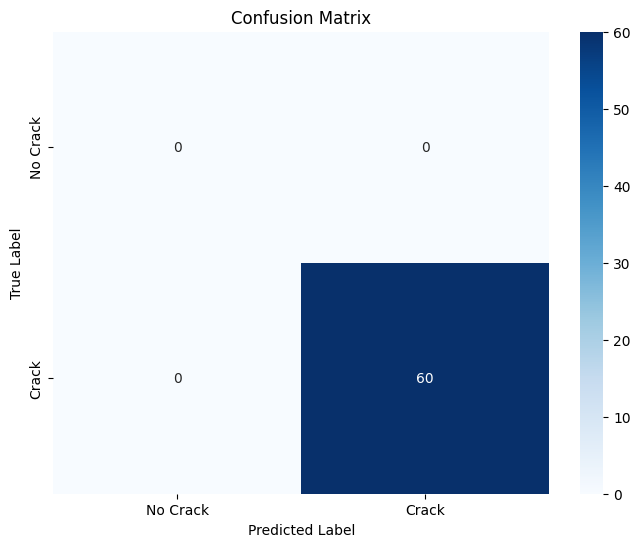

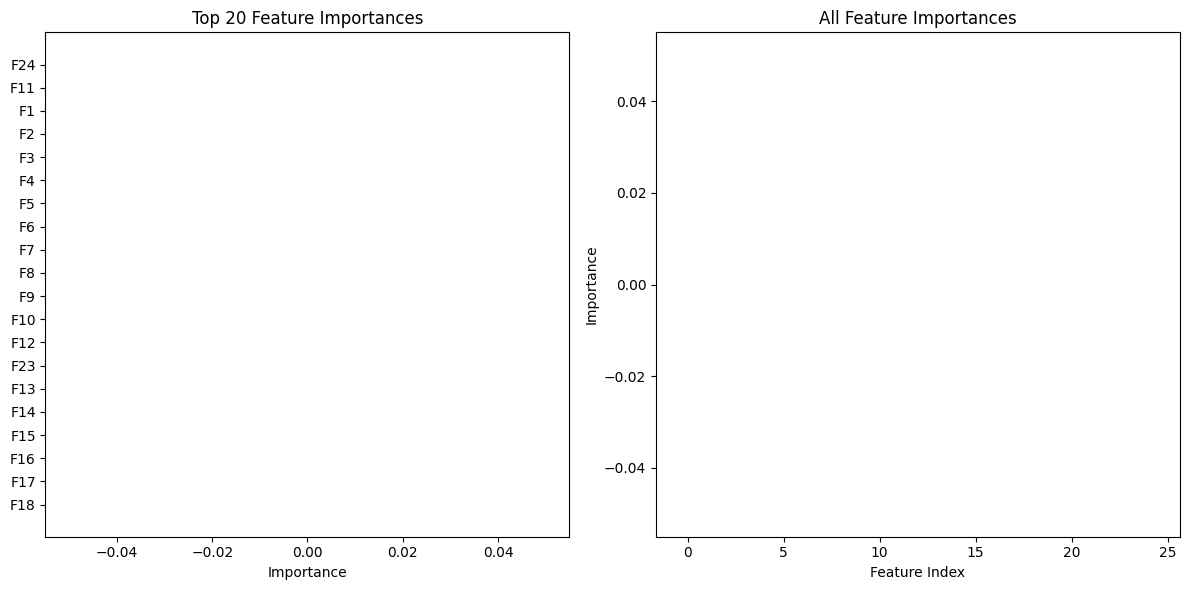


⚠️ Could not calculate ROC-AUC or F1 score


In [19]:
# Evaluate the model
if 'rf_model' in locals() and len(X_test) > 0:
    # Predictions
    y_pred = rf_model.predict(X_test_scaled)
    y_pred_proba = rf_model.predict_proba(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    print("📈 Model Performance:")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   Training Score: {rf_model.score(X_train_scaled, y_train):.4f}")
    print(f"   Testing Score: {rf_model.score(X_test_scaled, y_test):.4f}")
    
    # Debug information
    print(f"\n🔍 Debug Info:")
    print(f"   y_test shape: {y_test.shape}")
    print(f"   y_pred shape: {y_pred.shape}")
    print(f"   Unique values in y_test: {np.unique(y_test)}")
    print(f"   Unique values in y_pred: {np.unique(y_pred)}")
    
    # Classification Report with error handling
    print("\n📊 Classification Report:")
    try:
        # Method 1: Using labels parameter
        report = classification_report(y_test, y_pred, 
                                     labels=[0, 1], 
                                     target_names=['No Crack', 'Crack'],
                                     zero_division=0)
        print(report)
    except Exception as e:
        print(f"   Error with classification_report: {e}")
        # Manual calculation
        from sklearn.metrics import precision_recall_fscore_support
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, labels=[0, 1], zero_division=0
        )
        
        print("\n   Manual Metrics:")
        print(f"               precision    recall  f1-score   support")
        print(f"   No Crack     {precision[0]:.2f}       {recall[0]:.2f}       {f1[0]:.2f}       {support[0]:.0f}")
        print(f"   Crack        {precision[1]:.2f}       {recall[1]:.2f}       {f1[1]:.2f}       {support[1]:.0f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Crack', 'Crack'],
                yticklabels=['No Crack', 'Crack'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Feature Importance
    feature_importance = rf_model.feature_importances_
    
    plt.figure(figsize=(12, 6))
    
    # Plot top 20 features
    n_top_features = min(20, len(feature_importance))
    top_indices = np.argsort(feature_importance)[-n_top_features:]
    
    plt.subplot(1, 2, 1)
    plt.barh(range(n_top_features), feature_importance[top_indices])
    plt.yticks(range(n_top_features), [f'F{i}' for i in top_indices])
    plt.xlabel('Importance')
    plt.title(f'Top {n_top_features} Feature Importances')
    
    # Plot all features
    plt.subplot(1, 2, 2)
    plt.bar(range(len(feature_importance)), feature_importance)
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.title('All Feature Importances')
    
    plt.tight_layout()
    plt.show()
    
    # Additional metrics
    from sklearn.metrics import roc_auc_score, f1_score
    
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"\n📊 Additional Metrics:")
        print(f"   ROC-AUC Score: {roc_auc:.4f}")
        print(f"   F1-Score (weighted): {f1:.4f}")
    except:
        print("\n⚠️ Could not calculate ROC-AUC or F1 score")
    
else:
    print("❌ Model not trained or no test data available")
    
    # Check what's available
    print("\n🔍 Debug Info:")
    print(f"   rf_model exists: {'rf_model' in locals()}")
    if 'X_test' in locals():
        print(f"   X_test length: {len(X_test)}")
    if 'y_test' in locals():
        print(f"   y_test length: {len(y_test)}")

🔍 Testing on sample images:


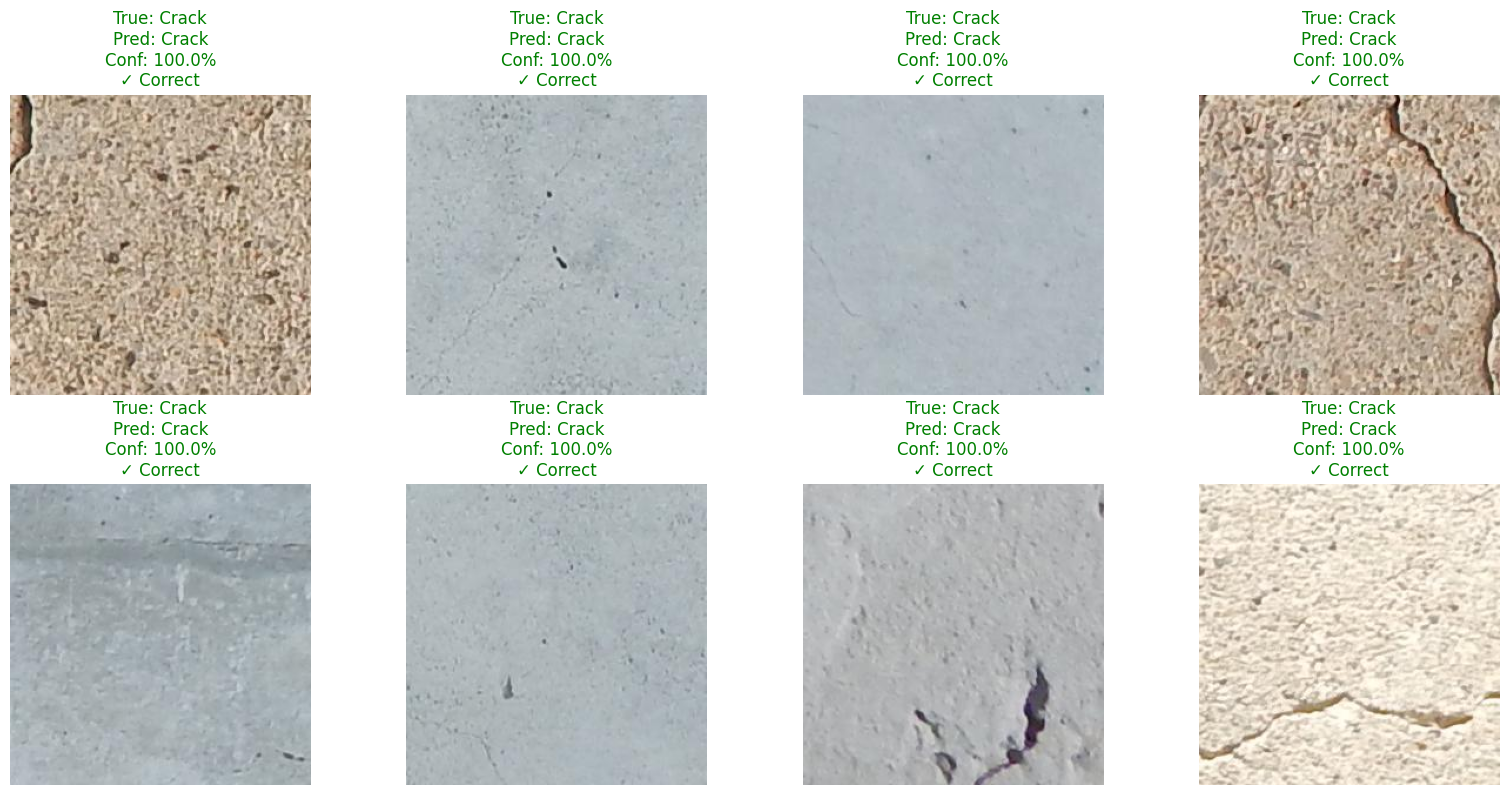

In [20]:
def predict_single_image(image_path, model, scaler):
    """Predict on a single image"""
    
    # Extract features
    features = extract_features(image_path)
    if features is None:
        return None, None
    
    # Scale features
    features_scaled = scaler.transform(features.reshape(1, -1))
    
    # Predict
    prediction = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0]
    
    return prediction, probability

# Test on some images from test set
if len(test_paths) > 0:
    print("🔍 Testing on sample images:")
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for i in range(min(8, len(test_paths))):
        img_path = test_paths[i]
        true_label = y_test[i]
        
        # Read and display image
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Predict
        pred, prob = predict_single_image(img_path, rf_model, scaler)
        
        # Display
        axes[i].imshow(img_rgb)
        axes[i].axis('off')
        
        if pred == true_label:
            color = 'green'
            status = '✓ Correct'
        else:
            color = 'red'
            status = '✗ Incorrect'
        
        axes[i].set_title(f"True: {'Crack' if true_label else 'No Crack'}\n"
                         f"Pred: {'Crack' if pred else 'No Crack'}\n"
                         f"Conf: {max(prob)*100:.1f}%\n"
                         f"{status}", color=color)
    
    plt.tight_layout()
    plt.show()

In [21]:
def get_llm_analysis(crack_analysis, ml_result, ml_confidence, metadata):
    """
    Get analysis from LLM (using Ollama)
    """
    
    # Prepare prompt for LLM
    prompt = f"""You are a senior civil engineer. Analyze this structural fault:

    📊 IMAGE ANALYSIS RESULTS:
    - ML Model Prediction: {ml_result} (Confidence: {ml_confidence:.1f}%)
    - Visual Crack Analysis:
      * Number of cracks detected: {crack_analysis['crack_count']}
      * Total crack area: {crack_analysis['total_crack_area']} pixels
      * Maximum crack length: {crack_analysis['max_crack_length']:.1f} pixels
      * Severity level: {crack_analysis['severity']}

    📝 STRUCTURE INFORMATION:
    {metadata}

    Based on civil engineering principles, provide a DETAILED REPORT with:

    1. FAULT IDENTIFICATION:
       - Type of structural fault
       - Affected structural element
       - Immediate risk assessment

    2. CAUSE ANALYSIS:
       - Likely causes
       - Contributing factors
       - Estimated timeline of occurrence

    3. PREVENTION MEASURES:
       - Design improvements
       - Maintenance recommendations
       - Monitoring techniques

    4. REMEDIATION:
       - Recommended repair methods
       - Urgency level
       - Estimated complexity

    Format as a professional engineering report."""
    
    try:
        # Try using Ollama (local)
        result = subprocess.run(
            ['ollama', 'run', 'phi3:mini', prompt],
            capture_output=True, text=True, timeout=30
        )
        return result.stdout
    
    except:
        try:
            # Fallback to Hugging Face API (free)
            API_URL = "https://api-inference.huggingface.co/models/mistralai/Mistral-7B-Instruct-v0.1"
            
            response = requests.post(API_URL, json={
                "inputs": prompt,
                "parameters": {"max_new_tokens": 500}
            })
            
            if response.status_code == 200:
                return response.json()[0]['generated_text']
            else:
                return get_fallback_response(crack_analysis)
        except:
            return get_fallback_response(crack_analysis)

def get_fallback_response(crack_analysis):
    """Fallback response if LLM is unavailable"""
    
    severity = crack_analysis['severity']
    
    if severity == "High":
        return """ENGINEERING REPORT (FALLBACK ANALYSIS)

1. FAULT IDENTIFICATION:
   - Type: Severe structural cracking detected
   - Element: Concrete structural member
   - Risk: IMMEDIATE - Structure requires urgent inspection

2. CAUSE ANALYSIS:
   - Possible overloading or material fatigue
   - May indicate reinforcement corrosion
   - Could be due to settlement or thermal stress

3. PREVENTION:
   - Regular structural inspections
   - Load monitoring systems
   - Proper drainage and waterproofing

4. REMEDIATION:
   - Immediate shoring required
   - Consult structural engineer urgently
   - Consider epoxy injection or replacement"""
    
    elif severity == "Medium":
        return """ENGINEERING REPORT (FALLBACK ANALYSIS)

1. FAULT IDENTIFICATION:
   - Type: Moderate cracking observed
   - Element: Concrete structure
   - Risk: MONITOR - Schedule detailed inspection

2. CAUSE ANALYSIS:
   - Likely shrinkage or minor settlement
   - Possible environmental factors
   - Normal wear and tear

3. PREVENTION:
   - Monitor crack propagation
   - Seal surface cracks
   - Improve drainage if external

4. REMEDIATION:
   - Fill cracks with appropriate sealant
   - Schedule follow-up in 3 months
   - Document for future reference"""
    
    else:
        return """ENGINEERING REPORT (FALLBACK ANALYSIS)

1. FAULT IDENTIFICATION:
   - Type: Minor surface imperfections
   - Element: Concrete surface
   - Risk: LOW - No immediate concern

2. CAUSE ANALYSIS:
   - Likely surface shrinkage
   - Normal curing-related cracks
   - Cosmetic in nature

3. PREVENTION:
   - Regular maintenance
   - Proper curing procedures
   - Quality control in construction

4. REMEDIATION:
   - Monitor during routine inspections
   - No immediate action required
   - Document in maintenance log"""

print("✅ LLM integration ready")

✅ LLM integration ready


In [22]:
def complete_analysis_pipeline(image_input, metadata="", model=None, scaler=None):
    """
    Complete pipeline: Image Processing -> ML Prediction -> LLM Analysis
    """
    
    # Load model if not provided
    if model is None:
        try:
            model = joblib.load('crack_detector_model.pkl')
            scaler = joblib.load('feature_scaler.pkl')
            print("✅ Model loaded successfully")
        except:
            print("❌ Could not load model")
            return None
    
    # Load image
    if isinstance(image_input, str):
        # If image path
        img = cv2.imread(image_input)
        if img is None:
            print(f"❌ Could not load image from {image_input}")
            return None
    else:
        # If numpy array
        img = image_input
    
    # Convert to RGB for display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Step 1: Basic image processing for crack analysis
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply threshold for crack detection
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Analyze cracks
    crack_areas = []
    crack_lengths = []
    
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 50:  # Filter noise
            crack_areas.append(area)
            perimeter = cv2.arcLength(contour, True)
            crack_lengths.append(perimeter)
    
    # Determine severity
    if len(crack_areas) > 0:
        max_area = max(crack_areas)
        if max_area > 1000:
            severity = "High"
        elif max_area > 200:
            severity = "Medium"
        else:
            severity = "Low"
        
        crack_count = len(crack_areas)
        total_area = sum(crack_areas)
        max_length = max(crack_lengths) if crack_lengths else 0
    else:
        severity = "None"
        crack_count = 0
        total_area = 0
        max_length = 0
    
    crack_analysis = {
        'crack_count': crack_count,
        'total_crack_area': total_area,
        'max_crack_length': max_length,
        'severity': severity
    }
    
    # Step 2: ML Prediction (if image path exists)
    ml_result = "N/A"
    ml_confidence = 0
    
    if isinstance(image_input, str):
        # Extract features for ML prediction
        features = extract_features(image_input)
        if features is not None:
            features_scaled = scaler.transform(features.reshape(1, -1))
            ml_pred = model.predict(features_scaled)[0]
            ml_prob = model.predict_proba(features_scaled)[0]
            
            ml_result = "Crack Detected" if ml_pred == 1 else "No Crack"
            ml_confidence = max(ml_prob) * 100
    
    # Step 3: LLM Analysis
    print("🔄 Getting LLM analysis...")
    llm_report = get_llm_analysis(crack_analysis, ml_result, ml_confidence, metadata)
    
    # Step 4: Visualize results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Threshold image
    axes[1].imshow(thresh, cmap='gray')
    axes[1].set_title('Crack Detection Mask')
    axes[1].axis('off')
    
    # Image with contours
    img_contours = img_rgb.copy()
    cv2.drawContours(img_contours, contours, -1, (255, 0, 0), 2)
    axes[2].imshow(img_contours)
    axes[2].set_title(f'Detected Cracks: {crack_count}')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print analysis
    print("\n" + "="*60)
    print("CIVIL ENGINEERING FAULT ANALYSIS REPORT")
    print("="*60)
    print(f"\n📊 IMAGE ANALYSIS:")
    print(f"   - Cracks detected: {crack_count}")
    print(f"   - Severity: {severity}")
    print(f"   - ML Prediction: {ml_result} ({ml_confidence:.1f}% confidence)")
    print(f"\n📝 METADATA:")
    print(f"   {metadata}")
    print(f"\n📄 DETAILED REPORT:")
    print("-"*40)
    print(llm_report)
    print("="*60)
    
    return {
        'crack_analysis': crack_analysis,
        'ml_result': ml_result,
        'ml_confidence': ml_confidence,
        'llm_report': llm_report,
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

print("✅ Analysis pipeline ready")

✅ Analysis pipeline ready


🔄 Getting LLM analysis...


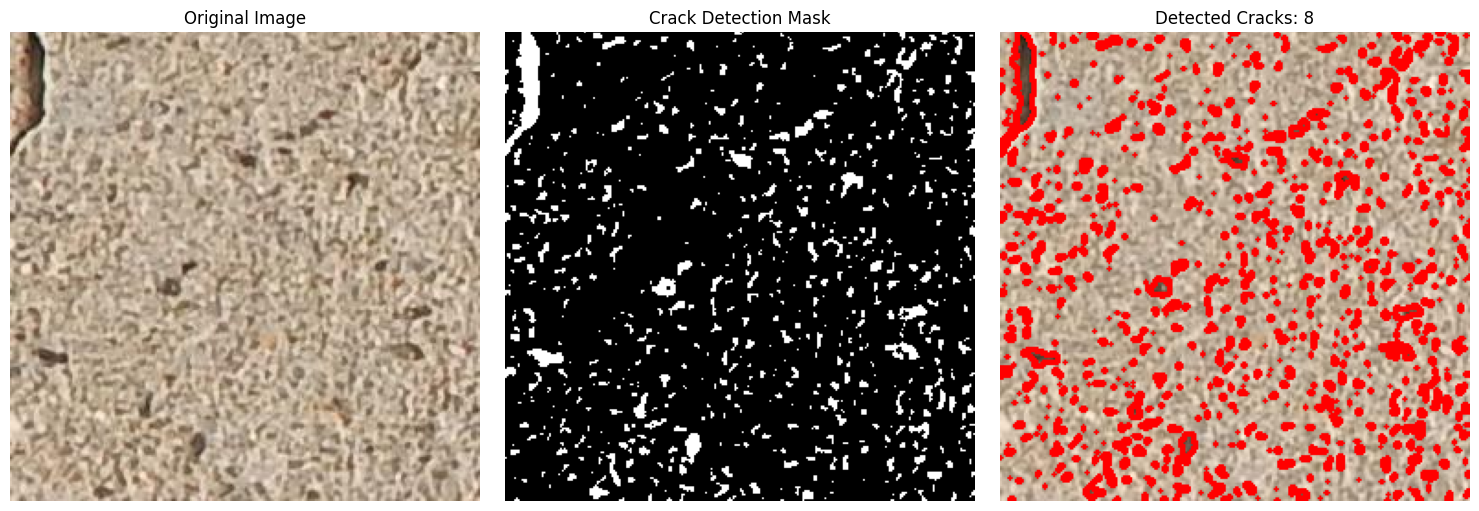


CIVIL ENGINEERING FAULT ANALYSIS REPORT

📊 IMAGE ANALYSIS:
   - Cracks detected: 8
   - Severity: Medium
   - ML Prediction: Crack Detected (100.0% confidence)

📝 METADATA:
   
    Location: Bridge Pillar #3, Highway 101
    Structure Type: Reinforced Concrete Bridge
    Inspection Date: 2024-01-15
    Environmental Conditions: Coastal area, high humidity
    Notes: Regular quarterly inspection
    

📄 DETAILED REPORT:
----------------------------------------
ENGINEERING REPORT (FALLBACK ANALYSIS)

1. FAULT IDENTIFICATION:
   - Type: Moderate cracking observed
   - Element: Concrete structure
   - Risk: MONITOR - Schedule detailed inspection

2. CAUSE ANALYSIS:
   - Likely shrinkage or minor settlement
   - Possible environmental factors
   - Normal wear and tear

3. PREVENTION:
   - Monitor crack propagation
   - Seal surface cracks
   - Improve drainage if external

4. REMEDIATION:
   - Fill cracks with appropriate sealant
   - Schedule follow-up in 3 months
   - Document for future

In [23]:
# Test the complete pipeline on a sample image
if len(test_paths) > 0:
    # Use a test image
    test_image_path = test_paths[0]
    
    # Sample metadata
    metadata = f"""
    Location: Bridge Pillar #3, Highway 101
    Structure Type: Reinforced Concrete Bridge
    Inspection Date: 2024-01-15
    Environmental Conditions: Coastal area, high humidity
    Notes: Regular quarterly inspection
    """
    
    # Run complete analysis
    result = complete_analysis_pipeline(
        image_input=test_image_path,
        metadata=metadata,
        model=rf_model,
        scaler=scaler
    )
    
    # Save report
    if result:
        report_text = f"""
CIVIL ENGINEERING FAULT ANALYSIS REPORT
=======================================
Generated: {result['timestamp']}

IMAGE ANALYSIS:
- Cracks Detected: {result['crack_analysis']['crack_count']}
- Severity: {result['crack_analysis']['severity']}
- Total Crack Area: {result['crack_analysis']['total_crack_area']} pixels
- ML Prediction: {result['ml_result']} ({result['ml_confidence']:.1f}% confidence)

METADATA:
{metadata}

DETAILED REPORT:
{result['llm_report']}
        """
        
        # Save to file
        filename = f"fault_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
        with open(filename, 'w') as f:
            f.write(report_text)
        print(f"\n💾 Report saved as: {filename}")

In [24]:
def interactive_test():
    """Interactive function to test with custom images"""
    
    print("🔧 Interactive Testing Mode")
    print("-" * 40)
    
    while True:
        print("\nOptions:")
        print("1. Test with image path")
        print("2. Test with random test image")
        print("3. Exit")
        
        choice = input("\nEnter choice (1-3): ")
        
        if choice == '1':
            img_path = input("Enter image path: ")
            if os.path.exists(img_path):
                metadata = input("Enter metadata (optional): ")
                complete_analysis_pipeline(img_path, metadata, rf_model, scaler)
            else:
                print("❌ Image not found!")
        
        elif choice == '2':
            if len(test_paths) > 0:
                import random
                img_path = random.choice(test_paths)
                print(f"Selected: {img_path}")
                metadata = "Test image from dataset"
                complete_analysis_pipeline(img_path, metadata, rf_model, scaler)
            else:
                print("❌ No test images available!")
        
        elif choice == '3':
            print("Exiting...")
            break
        
        else:
            print("❌ Invalid choice!")

# Uncomment to run interactive testing
# interactive_test()